In [1]:
import glob #importing glob library
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np

In [2]:
import astropy
import astropy.units as u
from astropy.utils.data import download_file
from astropy.io import fits  # We use fits to open the actual data file
from astropy.utils import data
from astropy.wcs import wcs
from astropy.visualization import (AsinhStretch, LogStretch, 
                                  PercentileInterval, ImageNormalize, simple_norm, ZScaleInterval)

In [3]:
from astropy.nddata import CCDData
import pandas as pd

from astropy.coordinates import SkyCoord

import ipywidgets as widgets
!pip install ipycanvas
from IPython.display import display

In [4]:
from ipycanvas import Canvas
from PIL import Image
from PIL import ImageTk
from tkinter import *

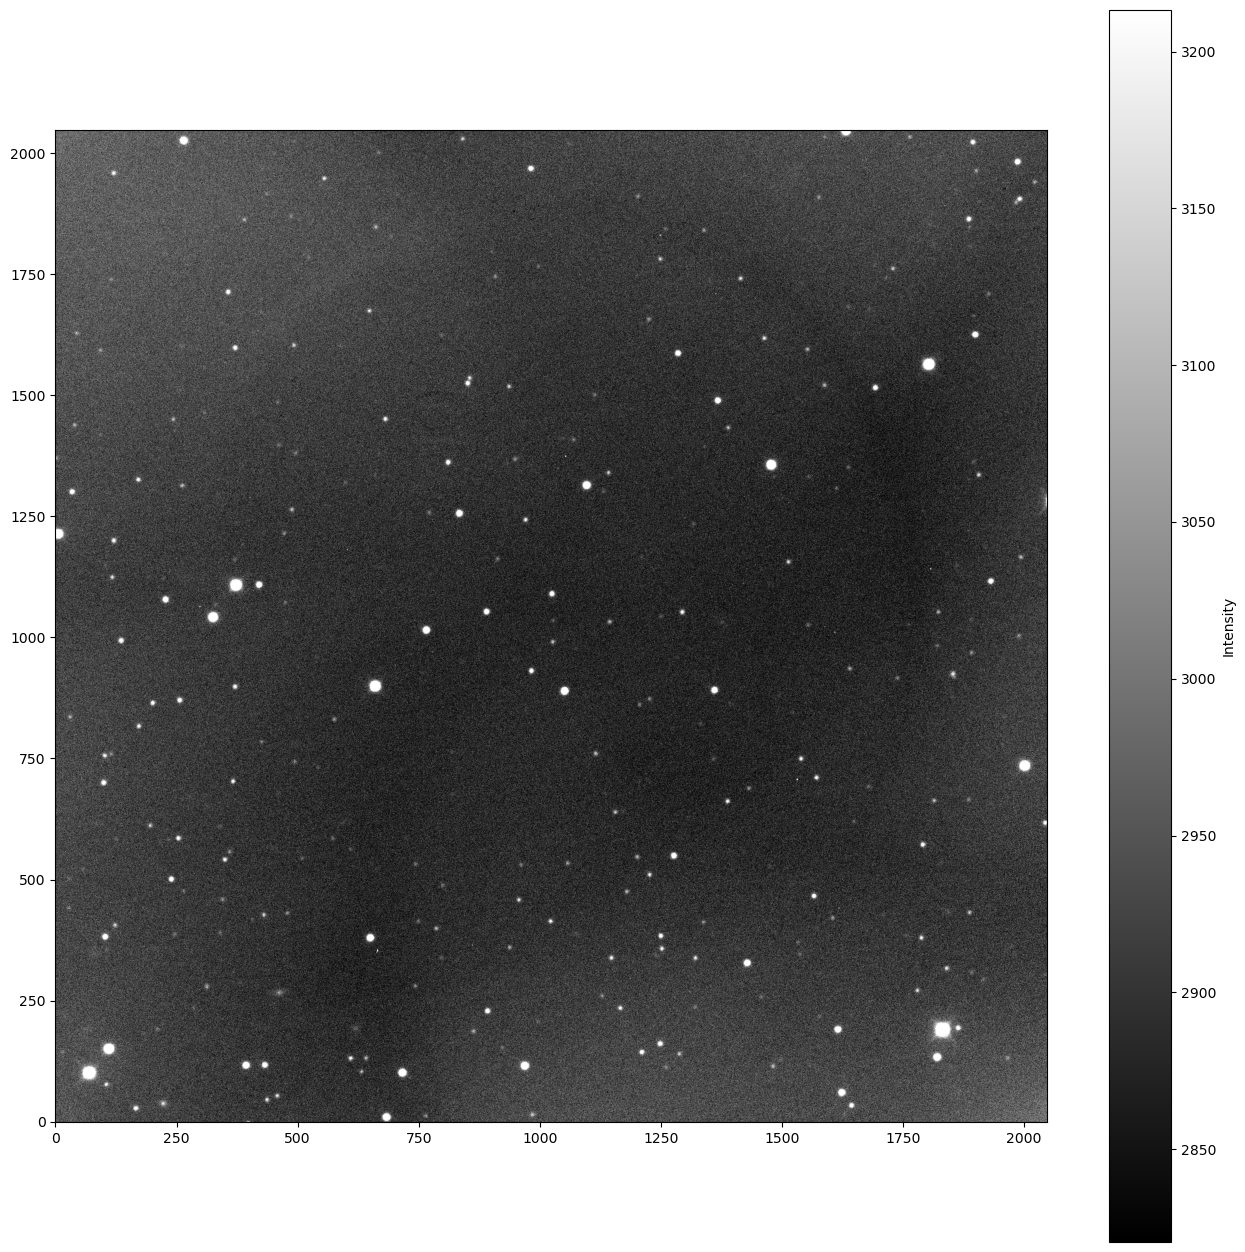

In [5]:
flat_image_data_1 = fits.getdata('C:/Users/isaac/Downloads/flat_fits_1.fits')
plt.figure(figsize=(16, 16))
image_data = np.nan_to_num(fits.open('C:/Users/isaac/Downloads/flat_fits_1.fits')[0].data)
interval = ZScaleInterval(n_samples=1000, contrast=0.25)
vmin, vmax = interval.get_limits(image_data)
if vmax <= vmin or (vmax - vmin) < 1e-5:
    interval = PercentileInterval(99.999)
    vmin, vmax = interval.get_limits(image_data)
img_median = np.median(image_data)
img_std = np.std(image_data)
data_range = vmax - vmin
vmin = vmin + (data_range * 0.18)
norm = ImageNormalize(image_data, vmin=vmin, vmax=vmax,)
plt.imshow(image_data, cmap='gray', norm=norm, origin='lower')
plt.colorbar(label='Intensity')
plt.show()

In [6]:
flat_image_data_1 = fits.getdata('C:/Users/isaac/Downloads/flat_fits_1.fits')
plt.figure(figsize=(16, 16))
image_data = np.nan_to_num(fits.open('C:/Users/isaac/Downloads/flat_fits_1.fits')[0].data)
interval =ZScaleInterval(n_samples=1000, contrast=0.25)
vmin,vmax = interval.get_limits(image_data)

if vmax <= vmin or (vmax - vmin) < 1e-5:
    interval = PercentileInterval(99.999)
    vmin, vmax = interval.get_limits(image_data)

data_range = vmax - vmin
vmin_adjusted = vmin +(data_range * 0.18)

clipped_image_data = np.clip(image_data, vmin_adjusted, vmax)
normalized = (clipped_image_data - vmin_adjusted) / (vmax - vmin_adjusted)
canvas_image = (normalized * 255).astype(np.uint8)


<Figure size 1600x1600 with 0 Axes>

In [9]:
from PIL import Image

root = Tk()
root.title("Pick Star")
root.geometry('900x700')

pil_img = Image.fromarray(canvas_image, mode='L')
tk_img = ImageTk.PhotoImage(image=pil_img, master=root)

hbar = Scrollbar(root, orient=HORIZONTAL)
hbar.pack(side=BOTTOM, fill=X)
vbar = Scrollbar(root, orient=VERTICAL)
vbar.pack(side=RIGHT, fill=Y)

canvas = Canvas(root, width=800, height=600,
                scrollregion=(0, 0, canvas_image.shape[1], canvas_image.shape[0]),
                xscrollcommand=hbar.set, yscrollcommand=vbar.set)
canvas.pack(side=LEFT, expand=True, fill=BOTH)

hbar.config(command=canvas.xview)
vbar.config(command=canvas.yview)
canvas.create_image(0, 0, anchor="nw", image=tk_img)

def give_coords(event):
    true_x = int(canvas.canvasx(event.x))
    true_y = int(canvas.canvasy(event.y))
    height, width = canvas_image.shape
    
    if 0 <= true_x < width and 0 <= true_y < height:
        pixel_value = image_data[true_y, true_x]
        print(f"FITS Coord: ({true_x}, {true_y}) | Intensity: {pixel_value}       ", end="\r")

canvas.bind('<Motion>', give_coords)

root.protocol("WM_DELETE_WINDOW", lambda: (root.quit(), root.destroy()))
root.mainloop()

FITS Coord: (876, 2) | Intensity: 2978.701416015625         